In [ ]:
import sys
import os
sys.path.append(os.path.abspath('d:/Dev/Quant'))

# 基于国信证券热点研报的策略、因子解析

本笔记本展示了 `gx_hotspot` 因子（基于 `SmoothReturn` 逻辑）的数学定义、计算过程以及基于工程化框架 `FactorTester` 的标准化检验。

**主要内容：**
1. **因子逻辑详解**：数学公式与核心思想。
2. **真实数据加载**：从本地 CSV 加载 A 股行情数据。
3. **标准化检验**：利用 `FactorTester` 集成的 Alphalens 功能进行全面评估。
4. **参数敏感性研究**：对比不同窗口长度对因子的影响。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from factors.technical_factors import HotspotFactors
from core.FactorTester import FactorTester

# 设置中文显示与绘图风格
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")


## 2. 真实数据加载与预处理

我们将从本地数据文件 `D:\DATA\all_stock_data_ts_20140102_20251231.csv` 中加载真实的股票日线数据。为了保证分析效率，我们将加载最近一两年的数据。

In [2]:
# 数据路径与参数设置
FACTOR_NAME = 'gx_hotspot_v3'
DATA_PATH = r'D:\DATA\all_stock_data_ts_20140102_20251231.csv'
START_DATE = '2020-01-01'  # 设定回测开始时间
END_DATE = '2025-12-31'    # 设定回测结束时间

print(f"正在从 {DATA_PATH} 加载数据...")

# 只加载必要列以节省内存
cols = ['date', 'code', 'close', 'open', 'high', 'low', 'volume']
df_list = []

# 由于文件可能较大，使用 chunksize 或直接读取并过滤
# 考虑到性能和内存，我们先定义一个简单的读取逻辑
try:
    full_df = pd.read_csv(DATA_PATH, usecols=cols)
    full_df['date'] = pd.to_datetime(full_df['date'])
    
    # 时间范围过滤
    full_df = full_df[(full_df['date'] >= START_DATE) & (full_df['date'] <= END_DATE)]
    
    # 格式化代码（确保 6 位代码）
    full_df['code'] = full_df['code'].astype(str).str.zfill(6)
    
    # 设置 MultiIndex 并排序
    full_df = full_df.set_index(['date', 'code']).sort_index()
    
    # 统计信息
    unique_dates = full_df.index.get_level_values('date').nunique()
    unique_codes = full_df.index.get_level_values('code').nunique()
    
    print(f"数据加载完成！")
    print(f"时间范围: {START_DATE} 至 {END_DATE}")
    print(f"交易日数: {unique_dates}, 股票数量: {unique_codes}")
    
except FileNotFoundError:
    print(f"错误: 找不到数据文件 {DATA_PATH}。请确认路径是否正确。")
except Exception as e:
    print(f"加载数据时出错: {e}")

正在从 D:\DATA\all_stock_data_ts_20140102_20251231.csv 加载数据...
数据加载完成！
时间范围: 2020-01-01 至 2025-12-31
交易日数: 1439, 股票数量: 5456


# 3. 准备数据并进行标准化检验

在计算完因子后，我们需要将其转换为 `FactorTester` 要求的格式并运行 Alphalens 测试。
`FactorTester` 需要因子的宽表（index=Date, columns=Asset）以及价格的宽表。

In [3]:
# 实例化因子类
hi = HotspotFactors()

print("开始计算 GX_hotspot 因子...")
# 计算 GX_hotspot (默认 20 日窗口)
# 注意：真实数据量大时，unstack 可能会占用较多内存
factor_results = hi.calculate_gx_hotspot(full_df, window_len=60)
full_df['gx_hotspot'] = factor_results['gx_hotspot']
full_df = full_df.sort_values(by=['code', 'date'])
full_df.to_parquet(f'D:/DATA/factors/{FACTOR_NAME}_{START_DATE}_{END_DATE}.parquet')  # 保存带因子的完整数据以供后续分析
full_df.to_csv(f'D:/DATA/factors/{FACTOR_NAME}_{START_DATE}_{END_DATE}.csv')  # 保存带因子的完整数据以供后续分析


开始计算 GX_hotspot 因子...


## 4. SmoothReturn 逻辑数学解释

`gx_hotspot` 因子的核心逻辑是衡量收益率的“方向性纯度”。如果股价一路上涨且回调极少，其因子值会非常高。

### 1. 方向强度 (Directional Strength)
首先计算窗口内收益率之和与收益率绝对值之和的比率。该值范围在 $[-1, 1]$ 之间。

$$Score_{raw} = \frac{\sum_{t=1}^{n} r_t}{\sum_{t=1}^{n} |r_t|}$$

* 如果 $ Score_{raw} = 1 $，说明窗口内每一天都在上涨。
* 如果 $ Score_{raw} = 0 $，说明上涨和下跌的幅度相互抵消。

### 2. 时间衰减权重 (Time Decay Weight)
为了惩罚交易不活跃或新上市的标的，引入了一个基于有效交易天数 $T$ 的惩罚因子。

$$W(T) = \min(1, \frac{\ln(T)}{\ln(40)})$$

### 3. 最终因子值 (Factor Value)
最终因子值是两者的乘积：

$$GX\_hotspot = Score_{raw} \cdot W(T)$$

该因子更偏好那些**波动小、趋势稳**的标的。

## 5. 使用 FactorTester 进行标准化检验

现在我们调用之前编写的 `FactorTester` 类，利用其集成的 Alphalens 功能进行更标准、更高效的因子分析。这将自动处理数据质量分析、相关性分析（如果是多因子）以及生成详细的分组收益、ICIR 统计等。

正在从 D:/DATA/factors/gx_hotspot_v3_2020-01-01_2025-12-31.parquet 加载已计算好的数据...
准备测试矩阵...
初始化完成，共加载 1 个因子
分析因子数据质量...
数据质量分析已保存至: d:\Dev\Quant\results\gx_hotspot/data_quality/数据质量分析报告.xlsx
开始预处理因子数据...
因子预处理完成, 耗时: 1.17秒
正在运行 Alphalens 标准测试 (max_loss=1.0)...
开始 Alphalens 单因子测试...
测试因子: gx_hotspot
Dropped 13.1% entries from factor data: 12.9% in forward returns computation and 0.2% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Alphalens 测试完成, 耗时: 11.76秒

=== IC/ICIR 统计摘要 ===


,IC_Mean_5,IC_IR_5,IC_Mean_20,IC_IR_20
Factor,,,,
gx_hotspot,-0.037199,-0.340005,-0.042884,-0.399386


IC/ICIR 汇总结果已保存至: d:\Dev\Quant\results\gx_hotspot\ic_icir_summary.csv

=== 生成分析图表 ===


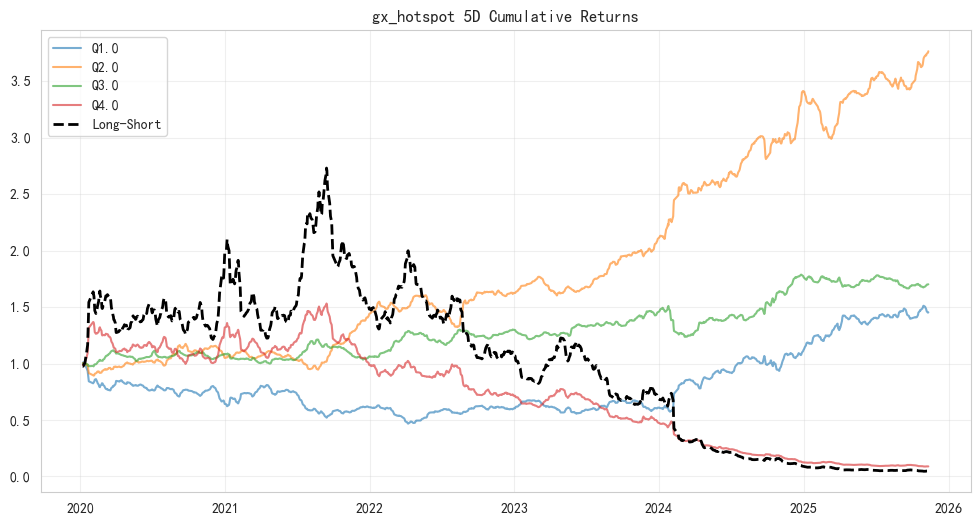

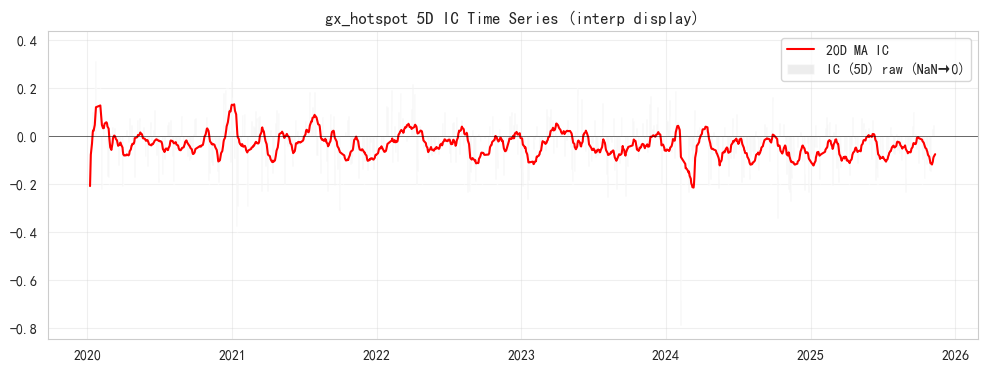

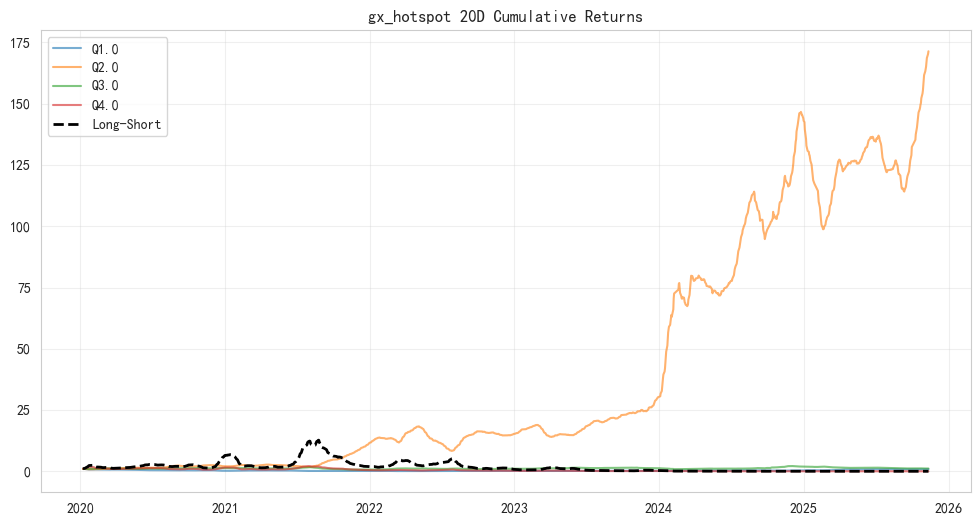

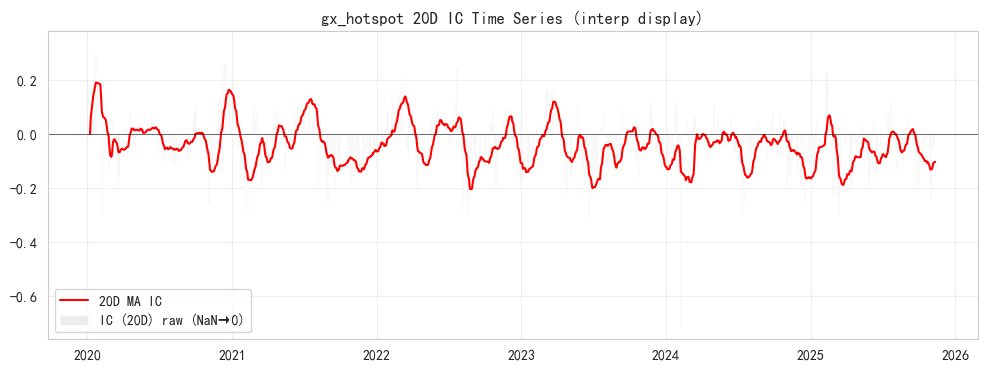

分析完成。结果保存至: d:\Dev\Quant\results\gx_hotspot


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import core.FactorTester
importlib.reload(core.FactorTester)
from core.FactorTester import FactorTester

# 1. 直接加载之前保存的 Parquet 数据
PARQUET_PATH = f'D:/DATA/factors/{FACTOR_NAME}_{START_DATE}_{END_DATE}.parquet'
print(f"正在从 {PARQUET_PATH} 加载已计算好的数据...")

# 读取数据
df_test = pd.read_parquet(PARQUET_PATH)

# 处理索引并确保格式正确
if isinstance(df_test.index, pd.MultiIndex):
    df_test = df_test.reset_index()

df_test['FDate'] = pd.to_datetime(df_test['date'])
df_test['SecCode'] = df_test['code']

# 准备价格和因子的宽表
print("准备测试矩阵...")
prices = df_test.pivot(index='FDate', columns='SecCode', values='close')

# 2. 初始化 FactorTester
output_dir = os.path.join(os.getcwd(), "results", "gx_hotspot")
os.makedirs(output_dir, exist_ok=True)

tester = FactorTester(
    factor_data=df_test[['FDate', 'SecCode', 'gx_hotspot']], 
    prices=prices, 
    output_dir=output_dir
)

# 3. 执行核心测试流程
# A. 数据质量分析
tester.analyze_data_quality()

# B. 因子预处理 (去极值、标准化)
tester.preprocess_factors(method="zscore")

# C. 执行核心 Alphalens 执行
try:
    print("正在运行 Alphalens 标准测试 (max_loss=1.0)...")
    
    # 删除了噪声扰动代码，直接进行测试
    results, summary = tester.run_alphalens_test(
        periods=(5, 20), 
        quantiles=4, 
        save_tearsheets=False, # 设置为 False，不再生成大量的 HTML 报告
        max_loss=1.0
    )
    
    # 打印统计摘要 (包含 IC, ICIR)
    print("\n=== IC/ICIR 统计摘要 ===")
    display(summary)
    
    # 保存 IC/ICIR 结果到 CSV
    summary_path = os.path.join(output_dir, "ic_icir_summary.csv")
    summary.to_csv(summary_path)
    print(f"IC/ICIR 汇总结果已保存至: {summary_path}")

    # 绘制结果图表
    print("\n=== 生成分析图表 ===")
    for factor_name, data in results.items():
        mean_ret_quantile = data['mean_ret_quantile']
        ic_data = data['ic'] # 获取原始 IC 时间序列
        
        # 保存原始 IC 数据
        ic_path = os.path.join(output_dir, f"{factor_name}_ic_series.csv")
        ic_data.to_csv(ic_path)
        
        for p in (5, 20):
            col = f'{p}D' if f'{p}D' in mean_ret_quantile.columns else p
            if col in mean_ret_quantile.columns:
                ret_q = mean_ret_quantile[col].unstack('factor_quantile')
                ret_q.index = pd.to_datetime(ret_q.index)
                cum_ret_q = (1 + ret_q).cumprod()
                
                # 多空曲线
                ls_ret = ret_q[ret_q.columns[-1]] - ret_q[ret_q.columns[0]]
                cum_ls = (1 + ls_ret).cumprod()
                
                # --- 图表 1: 累积收益 (分开绘制) ---
                plt.figure(figsize=(12, 6))
                for q in cum_ret_q.columns:
                    plt.plot(cum_ret_q.index, cum_ret_q[q], label=f'Q{q}', alpha=0.6)
                plt.plot(cum_ls.index, cum_ls, label='Long-Short', color='black', linewidth=2, linestyle='--')
                plt.title(f'{factor_name} {p}D Cumulative Returns')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.savefig(f"{output_dir}/{factor_name}_{p}D_cumulative_returns.png")
                plt.show()
                plt.close()
                
                # --- 图表 2: IC 时间序列 (改进：对 NaN 更宽容，插值以保证可视连续性) ---
                ic_col = f'{p}D' if f'{p}D' in ic_data.columns else p
                if ic_col in ic_data.columns:
                    # 原始 IC 序列（将用户可能用 -1 标记的无信号位视为缺失）
                    ic_series = ic_data[ic_col].copy().replace(-1, np.nan)

                    # 用短距离插值保持可视上的连续性，再前向/后向填充边界
                    ic_plot = ic_series.interpolate(limit=5).fillna(method='ffill').fillna(method='bfill')

                    # 滚动平均基于插值后的序列（不会因为局部 NaN 导致断裂）
                    ma_ic = ic_plot.rolling(20, min_periods=1).mean()

                    plt.figure(figsize=(12, 4))
                    # 保留柱状图展示原始（NaN 被绘为 0 以示缺失），线图展示插值连续曲线
                    plt.bar(ic_plot.index, ic_series.fillna(0), alpha=0.4, color='lightgray', label=f'IC ({p}D) raw (NaN→0)')
                    # plt.plot(ic_plot.index, ic_plot, color='blue', label='IC (interpolated)', linewidth=1)
                    plt.plot(ma_ic.index, ma_ic, color='red', label='20D MA IC', linewidth=1.5)
                    plt.axhline(0, color='black', lw=0.4)
                    plt.title(f'{factor_name} {p}D IC Time Series (interp display)')
                    plt.legend()
                    plt.grid(True, alpha=0.3)
                    plt.savefig(f"{output_dir}/{factor_name}_{p}D_ic_series.png")
                    plt.show()
                    plt.close()

except Exception as e:
    print(f"测试出错: {e}")

print(f"分析完成。结果保存至: {output_dir}")